In [2]:
import os

print(os.getcwd())
print(os.listdir())

/Users/vidhi/Desktop/alfido-tech-internship/Task-2 House Price Prediction
['Task-2 House Price Prediction.ipynb', 'house_price_model.joblib', 'data.csv', '.ipynb_checkpoints']


# House Price Prediction using Machine Learning

## Objective
The objective of this project is to build a regression model that predicts house prices using property features.

## Algorithms Used
- Linear Regression
- Random Forest Regressor
- Gradient Boosting Regressor

## Evaluation Metrics
- Root Mean Squared Error (RMSE)
- Mean Absolute Error (MAE)
- Residual Analysis

In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [4]:
df = pd.read_csv("data.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (4600, 18)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,2014-05-02 00:00:00,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,2014-05-02 00:00:00,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,2014-05-02 00:00:00,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,2014-05-02 00:00:00,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   object 
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   float64
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   object 
 15  city           4600 non-null   object 
 16  statezip       4600 non-null   object 
 17  country        4600 non-null   object 
dtypes: float

In [6]:
df.isnull().sum().sort_values(ascending=False)

date             0
price            0
statezip         0
city             0
street           0
yr_renovated     0
yr_built         0
sqft_basement    0
sqft_above       0
condition        0
view             0
waterfront       0
floors           0
sqft_lot         0
sqft_living      0
bathrooms        0
bedrooms         0
country          0
dtype: int64

In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,4600.0,551962.988473,563834.702547,0.0,322875.00,460943.461539,654962.50,26590000.0
bedrooms,4600.0,3.400870,0.908848,0.0,3.00,3.000000,4.00,9.0
bathrooms,4600.0,2.160815,0.783781,0.0,1.75,2.250000,2.50,8.0
sqft_living,4600.0,2139.346957,963.206916,370.0,1460.00,1980.000000,2620.00,13540.0
sqft_lot,4600.0,14852.516087,35884.436145,638.0,5000.75,7683.000000,11001.25,1074218.0
floors,4600.0,1.512065,0.538288,1.0,1.00,1.500000,2.00,3.5
waterfront,4600.0,0.007174,0.084404,0.0,0.00,0.000000,0.00,1.0
view,4600.0,0.240652,0.778405,0.0,0.00,0.000000,0.00,4.0
condition,4600.0,3.451739,0.677230,1.0,3.00,3.000000,4.00,5.0
sqft_above,4600.0,1827.265435,862.168977,370.0,1190.00,1590.000000,2300.00,9410.0


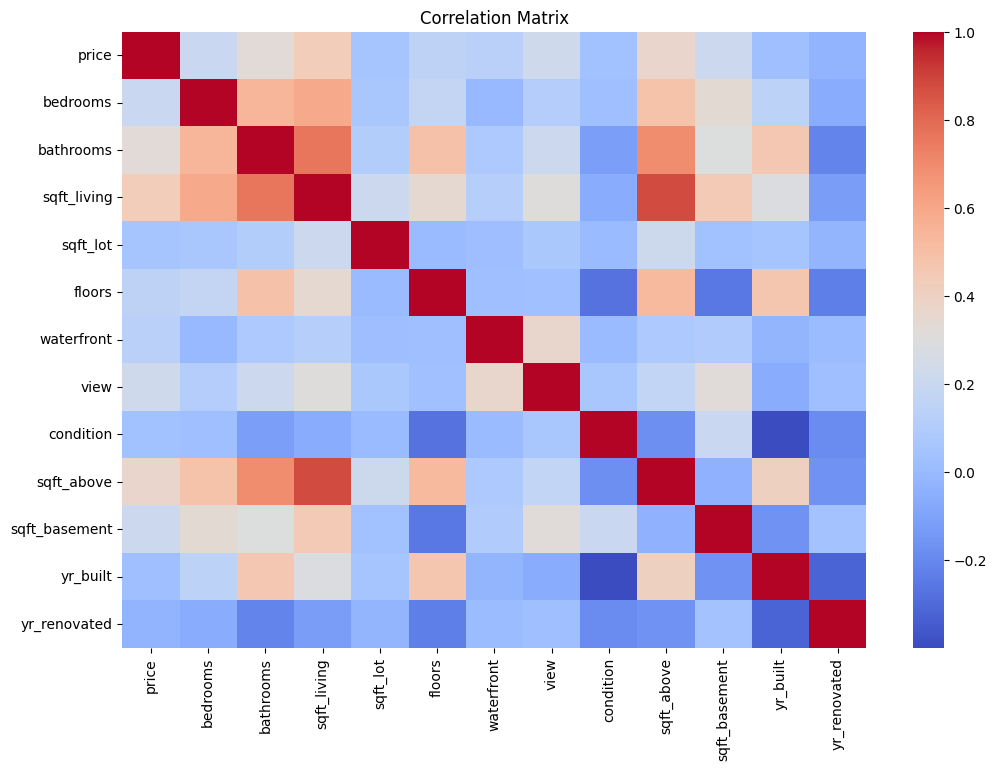

In [8]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    cmap="coolwarm",
    annot=False
)

plt.title("Correlation Matrix")
plt.show()

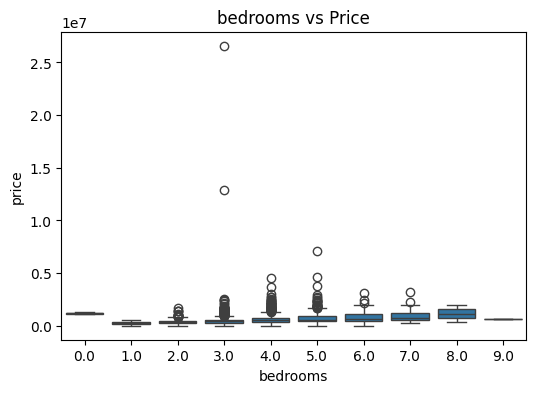

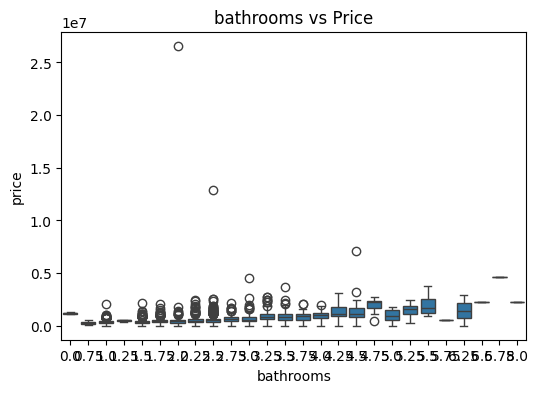

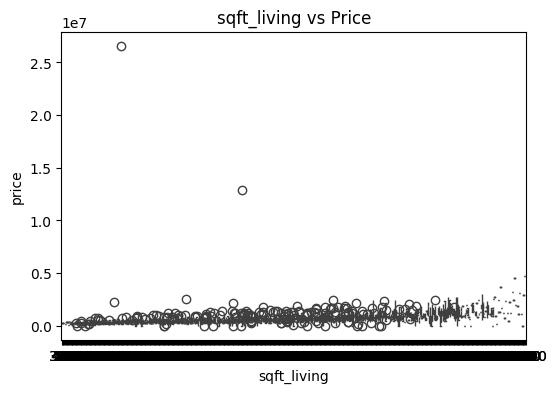

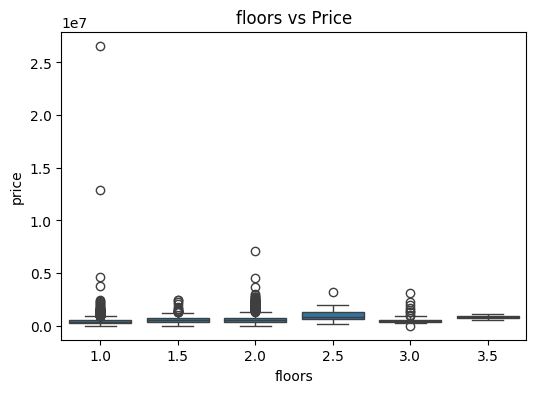

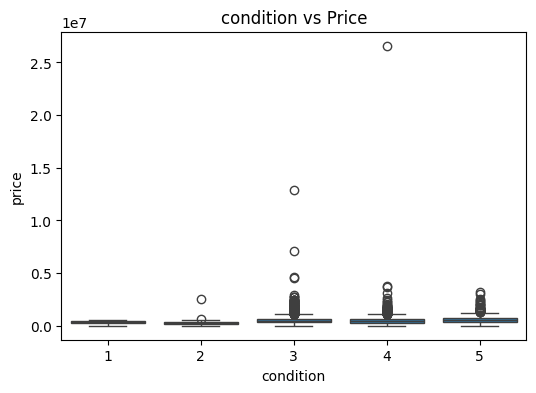

In [9]:
numeric_cols = [
    "bedrooms",
    "bathrooms",
    "sqft_living",
    "floors",
    "condition"
]

for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.boxplot(x=df[col], y=df["price"])
    plt.title(f"{col} vs Price")
    plt.show()

In [40]:
df = df[df["price"] > 0].copy()
Q1 = df["price"].quantile(0.25)
Q3 = df["price"].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df["price"] >= lower) & (df["price"] <= upper)].copy()

print(df.shape)

(4311, 24)


In [58]:
# Convert date to datetime
df["date"] = pd.to_datetime(df["date"])

# Date Features
df["sale_year"] = df["date"].dt.year
df["sale_month"] = df["date"].dt.month

# House Age
df["house_age"] = df["sale_year"] - df["yr_built"]

# Renovation Age
df["renovation_age"] = np.where(
    df["yr_renovated"] == 0,
    0,
    df["sale_year"] - df["yr_renovated"]
)

# Total Area
df["total_sqft"] = df["sqft_above"] + df["sqft_basement"]
df["bath_per_bed"] = df["bathrooms"] / (df["bedrooms"] + 1)

# Log transform target
df["log_price"] = np.log1p(df["price"])

print("Feature Engineering Completed")

Feature Engineering Completed


In [59]:
X = df.drop(
    columns=[
        "price",
        "log_price",
        "date",
        "street",
        "country"
    ]
)

y = df["log_price"]

print("Shape of X:", X.shape)
print("Shape of y:", y.shape)

Shape of X: (4311, 20)
Shape of y: (4311,)


In [60]:
categorical_features = X.select_dtypes(include=["object"]).columns

numerical_features = X.select_dtypes(exclude=["object"]).columns

print("Categorical Features")
print(categorical_features)

print("\nNumerical Features")
print(numerical_features)

Categorical Features
Index(['city', 'statezip'], dtype='object')

Numerical Features
Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'sale_year', 'sale_month', 'house_age',
       'renovation_age', 'total_sqft', 'bath_per_bed'],
      dtype='object')


In [61]:
numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_transformer, numerical_features),
    ("cat", categorical_transformer, categorical_features)
])

In [62]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(3448, 20)
(863, 20)


In [63]:
models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=700,
        max_depth=30,
        min_samples_split=2,
        random_state=42,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.9,
        random_state=42
    )
}

In [64]:
results = []

trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    predictions = pipeline.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    mae = mean_absolute_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)

    trained_models[name] = pipeline

    results.append({
        "Model": name,
        "RMSE": rmse,
        "MAE": mae,
        "R² Score": r2
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
)

results_df

,Model,RMSE,MAE,R² Score
1,Gradient Boosting,0.211768,0.148995,0.778888
0,Random Forest,0.235847,0.165369,0.725747


In [66]:
from sklearn.metrics import r2_score

best_model = trained_models["Gradient Boosting"]

train_score = best_model.score(X_train, y_train)
test_score = best_model.score(X_test, y_test)

print("Train R²:", train_score)
print("Test R² :", test_score)

Train R²: 0.9371150174364464
Test R² : 0.7788876713525957


In [67]:
print("Categorical Features:")
print(categorical_features)

print("\nNumerical Features:")
print(numerical_features)

Categorical Features:
Index(['city', 'statezip'], dtype='object')

Numerical Features:
Index(['bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
       'waterfront', 'view', 'condition', 'sqft_above', 'sqft_basement',
       'yr_built', 'yr_renovated', 'sale_year', 'sale_month', 'house_age',
       'renovation_age', 'total_sqft', 'bath_per_bed'],
      dtype='object')


In [68]:
print(df.shape)
df.head()

(4311, 25)


,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,city,statezip,country,sale_year,sale_month,house_age,renovation_age,total_sqft,log_price,bath_per_bed
0,2014-05-02,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,...,Shoreline,WA 98133,USA,2014,5,59,9,1340,12.653962,0.375000
2,2014-05-02,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,...,Kent,WA 98042,USA,2014,5,48,0,1930,12.742569,0.500000
3,2014-05-02,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,...,Bellevue,WA 98008,USA,2014,5,51,0,2000,12.948012,0.562500
4,2014-05-02,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,...,Redmond,WA 98052,USA,2014,5,38,22,1940,13.217675,0.500000
5,2014-05-02,490000.0,2.0,1.00,880,6380,1.0,0,0,3,...,Seattle,WA 98115,USA,2014,5,76,20,880,13.102163,0.333333


In [69]:
print(df.dtypes)

date              datetime64[ns]
price                    float64
bedrooms                 float64
bathrooms                float64
sqft_living                int64
sqft_lot                   int64
floors                   float64
waterfront                 int64
view                       int64
condition                  int64
sqft_above                 int64
sqft_basement              int64
yr_built                   int64
yr_renovated               int64
street                    object
city                      object
statezip                  object
country                   object
sale_year                  int32
sale_month                 int32
house_age                  int64
renovation_age             int64
total_sqft                 int64
log_price                float64
bath_per_bed             float64
dtype: object


In [70]:
df["price"].describe()

count    4.311000e+03
mean     4.874569e+05
std      2.156596e+05
min      7.800000e+03
25%      3.200000e+05
50%      4.500000e+05
75%      6.150000e+05
max      1.150000e+06
Name: price, dtype: float64

In [71]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [72]:
print(df["city"].nunique())
print(df["statezip"].nunique())

44
77


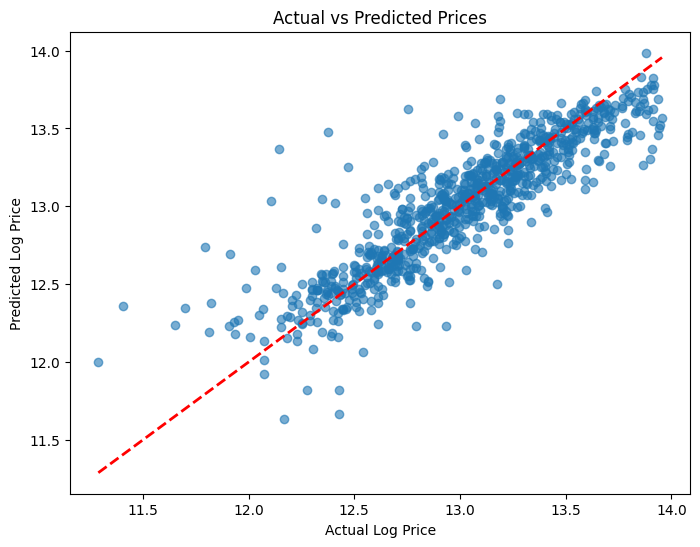

In [73]:
import matplotlib.pyplot as plt

best_model = trained_models["Gradient Boosting"]

y_pred = best_model.predict(X_test)

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)

plt.xlabel("Actual Log Price")
plt.ylabel("Predicted Log Price")
plt.title("Actual vs Predicted Prices")
plt.show()

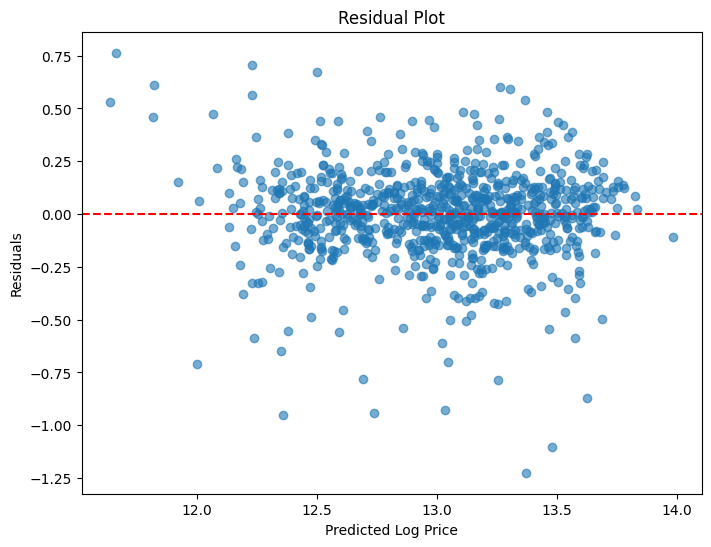

In [74]:
residuals = y_test - y_pred

plt.figure(figsize=(8,6))
plt.scatter(y_pred, residuals, alpha=0.6)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Log Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

In [75]:
import pandas as pd

model = trained_models["Gradient Boosting"].named_steps["model"]

feature_names = trained_models["Gradient Boosting"]\
.named_steps["preprocessor"]\
.get_feature_names_out()

importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(15)

,Feature,Importance
16,num__total_sqft,0.236760
2,num__sqft_living,0.157135
52,cat__city_Seattle,0.067602
3,num__sqft_lot,0.038940
8,num__sqft_above,0.035054
19,cat__city_Auburn,0.029963
21,cat__city_Bellevue,0.028791
36,cat__city_Kent,0.027955
32,cat__city_Federal Way,0.025792
1,num__bathrooms,0.019427


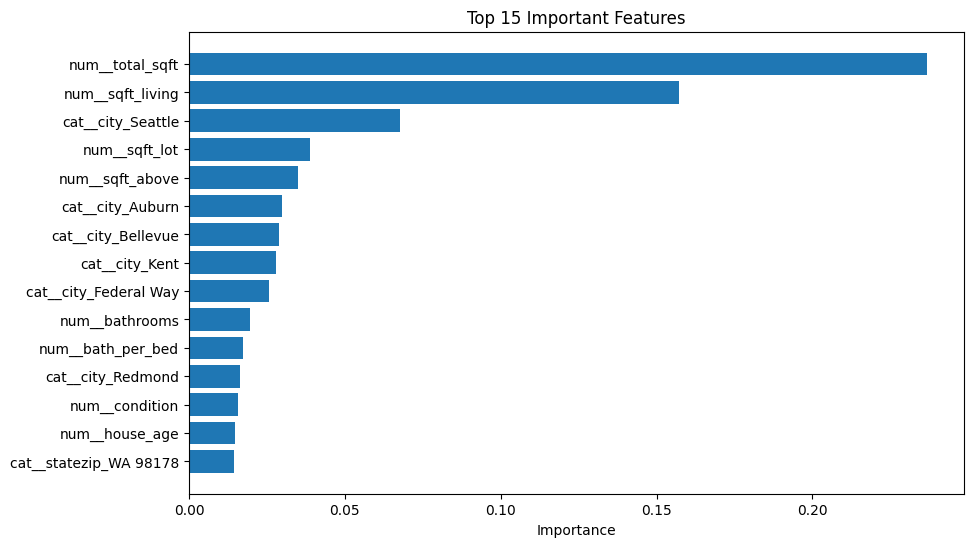

In [76]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"][:15],
    importance["Importance"][:15]
)

plt.gca().invert_yaxis()

plt.title("Top 15 Important Features")

plt.xlabel("Importance")

plt.show()

In [77]:
import joblib

joblib.dump(
    trained_models["Gradient Boosting"],
    "house_price_model.joblib"
)

print("Model Saved Successfully!")

Model Saved Successfully!


In [78]:
sample = X_test.iloc[[0]]

prediction = trained_models["Gradient Boosting"].predict(sample)

actual_price = np.expm1(y_test.iloc[0])
predicted_price = np.expm1(prediction[0])

print("Actual Price    : ₹{:,.2f}".format(actual_price))
print("Predicted Price : ₹{:,.2f}".format(predicted_price))

Actual Price    : ₹378,000.00
Predicted Price : ₹344,465.80


# Conclusion

- Performed data cleaning and preprocessing.
- Conducted exploratory data analysis (EDA).
- Engineered new features such as house age and renovation age.
- Compared Random Forest and Gradient Boosting regressors.
- Gradient Boosting achieved the best performance.

### Best Model Performance

- **Model:** Gradient Boosting Regressor
- **R² Score:** ~0.78
- **RMSE:** ~0.21
- **MAE:** ~0.15

The trained model was successfully saved for future predictions.